if-else in workflow - Contional Workflow

##Quadratic Equation workflow

In [4]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [6]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int 
    
    equation: str
    discriminant: float
    result: str

In [13]:
def show_equation(state: QuadState):
    equation = f"{state["a"]}x^2 + {state['b']}x + {state['c']}"
    
    return {'equation': equation}

def calculate_discriminant(state: QuadState):
    discriminant= state['b']**2 - (4*state['a']*state['c'])
    
    return {'discriminant': discriminant}

def real_roots(state: QuadState):
    root1= (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    root2= (-state['b'] - state['discriminant']**0.5) / (2*state['a'])
    return {'result': f"Two real roots: {root1} and {root2}"}   

def repeated_roots(state: QuadState):
    root= (-state['b'] / (2*state['a']))
    return {'result': f"Two real roots: {root}"}   

def no_real_roots(state: QuadState):
    return {'result': "No real roots"}

def check_condition(state: QuadState)-> Literal["real_roots","repeated_roots","no_real_roots"]:
    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'repeated_roots'
    else:
        return 'no_real_roots'

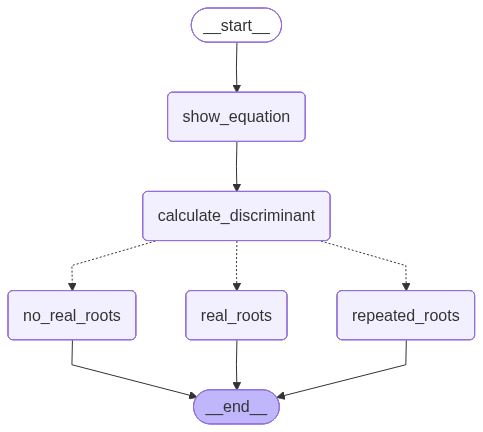

In [15]:
graph = StateGraph(QuadState)

graph.add_node("show_equation", show_equation)
graph.add_node("calculate_discriminant", calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "calculate_discriminant")

graph.add_conditional_edges('calculate_discriminant',check_condition)
graph.add_edge("real_roots", END)
graph.add_edge("repeated_roots", END)
graph.add_edge("no_real_roots", END)

workflow = graph.compile()

workflow



In [16]:
initial_state = {
    'a': 4,
    'b': -5,
    'c': -4
}

workflow.invoke(initial_state)


{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x^2 + -5x + -4',
 'discriminant': 89,
 'result': 'Two real roots: 1.8042476415070754 and -0.5542476415070754'}

Conditional LangGraph with LLM

In [1]:
from langgraph.graph import StateGraph, START,  END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

c:\CODE\Personal\AI-and-ML\venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
load_dotenv()

True

In [4]:
model= ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive','negative']=Field(description='Sentiment of the review')

In [23]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal['UX','Performance','Bug','Support','Other']=Field(description='decribe the type of the issue the reviewer is facing. ')
    tone: Literal ['angrey','frustrated','disappointed','calm']=Field(description='The emotion of the reviewer in the review message.')
    urgency: Literal['low','medium','high'] = Field(description="How urgent or critical is the issue.")
    

In [24]:
structured_model=model.with_structured_output(SentimentSchema)
struct_model2=model.with_structured_output(DiagnosisSchema)

In [15]:
prompt= "what is the sentiment of the following review- the software is good"
structured_model.invoke(prompt).sentiment

'positive'

In [16]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['posoitive','negative']
    diagnosis: dict
    response: str
    

In [26]:
def find_sentiment(state: ReviewState):
    
    prompt= f"for the following review find out thte sentiment \n {state['review']}"
    sentiment=structured_model.invoke(prompt).sentiment
    
    return {'sentiment':sentiment }

def check_sentiment(state:ReviewState)-> Literal ['positive_response','run_diagnosis']:
    if state['sentiment']== 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state:ReviewState):
    prompt=f"Write a warm thank you message in the response to this review: \n {state['review']}.\nAlso, kindly ask the user to leave a feedback on our website."
    
    response=model.invoke(prompt).content
    return {'response': response}
    
def run_diagnosis(state:ReviewState):
    prompt= f"Diagnose thsi negative review : \n {state['review']}.\n Return issue type, tone and urgency."
    
    response=struct_model2.invoke(prompt)
    
    return {'diagnosis': response.model.dump()}
    
    
def negative_response(state:ReviewState):
    prompt=f"You are a support assistant. The User has a {state['diagnosis'['issue_type']]} issue, sounded '{state['diagnosis'['tone']]}', and marked urgency as '{state['diagnosis'['urgency']]}. \n Write a empathetic, helphul resolution message."
    response=model.invoke(prompt).content
    
    return {'response': response}
    
    

<>:29: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:29: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:29: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:29: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:29: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
<>:29: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
C:\Users\YatharthPatankar\AppData\Local\Temp\ipykernel_12736\55090933.py:29: SyntaxWarning: str indices must be integers or slices, not str; perhaps you missed a comma?
  prompt=f"You are a support assistant. The User has a {state['diagnosis'['issue_type']]} issue, sounded '{state['diagnosis'['tone']]}', and marked urgency as '{state['diagnosis'['urgency']]}. \n Write a empathetic, helphul resolution me

In [31]:
graph= StateGraph(ReviewState)

graph.add_node('find_sentiment',find_sentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)

graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)

graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)




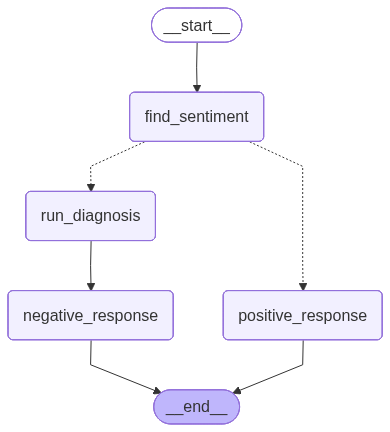

In [32]:
workflow=graph.compile()
workflow

In [33]:
initial_state= {
    'review':'the product is really good.'
}

workflow.invoke(initial_state)

{'review': 'the product is really good.',
 'sentiment': 'positive',
 'response': "Dear valued customer,\n\nWe wanted to take a moment to express our heartfelt thanks for your wonderful review. We're thrilled to hear that you're enjoying our product - it's always great to know that our efforts are making a positive impact.\n\nAs a small token of our appreciation, we'd love to hear more about your experience with us. If you have a spare moment, could you kindly leave a feedback on our website? Your input will not only help us to improve, but also assist others in making informed decisions.\n\nOnce again, thank you for your kind words and for being an important part of our community. We look forward to serving you better in the future.\n\nBest regards, [Your Name]"}